## Setup and Libraries

In [17]:

!pip install tensorflow opencv-python-headless

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import numpy as np
import os
import cv2
from sklearn.metrics import classification_report


## Data Loading and Preprocessing

In [21]:
# Define dataset path
import kagglehub


path = kagglehub.dataset_download("hereisburak/pins-face-recognition")

print("Path to dataset files:", path)
# Define the dataset path (your specified path)
dataset_path = "/root/.cache/kagglehub/datasets/hereisburak/pins-face-recognition/versions/1/105_classes_pins_dataset/"

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Image parameters
img_size = 100
batch_size = 32

# Data Augmentation and Preprocessing
datagen = ImageDataGenerator(
    rescale=1./255,  # Normalize pixel values
    validation_split=0.2  # 80% training, 20% validation
)

# Load training and validation data
train_data = datagen.flow_from_directory(
    '/root/.cache/kagglehub/datasets/hereisburak/pins-face-recognition/versions/1/105_classes_pins_dataset/',  # Update the path to your dataset
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    '/root/.cache/kagglehub/datasets/hereisburak/pins-face-recognition/versions/1/105_classes_pins_dataset/',  # Update the path to your dataset
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

# Number of unique people (classes)
num_classes = len(train_data.class_indices)



Path to dataset files: /root/.cache/kagglehub/datasets/hereisburak/pins-face-recognition/versions/1
Found 14071 images belonging to 105 classes.
Found 3463 images belonging to 105 classes.


## Build the Artificial Neural Network (ANN) Model

In [22]:
# Learning rate scheduler function
def lr_schedule(epoch, lr):
    if epoch > 3:
        return lr * 0.95  # Reduce learning rate after 3 epochs
    return lr

# Build the ANN model
model = Sequential([
    # Input layer: Flatten the image
    Flatten(input_shape=(img_size, img_size, 3)),

    # First hidden layer with 512 neurons and ReLU
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),  # Dropout to prevent overfitting

    # Second hidden layer with 256 neurons and ReLU
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    # Third hidden layer with 128 neurons and ReLU
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    # Output layer with 'num_classes' neurons (Softmax for classification)
    Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Model summary
model.summary()


Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_3 (Flatten)         (None, 30000)             0         
                                                                 
 dense_10 (Dense)            (None, 512)               15360512  
                                                                 
 batch_normalization_7 (Bat  (None, 512)               2048      
 chNormalization)                                                
                                                                 
 dropout_7 (Dropout)         (None, 512)               0         
                                                                 
 dense_11 (Dense)            (None, 256)               131328    
                                                                 
 batch_normalization_8 (Bat  (None, 256)               1024      
 chNormalization)                                     

## Train the Model

In [24]:
# Define callbacks: Early stopping and learning rate scheduler
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_scheduler = LearningRateScheduler(lr_schedule)

# Train the model
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=100,  
    callbacks=[early_stopping, lr_scheduler]
)


Epoch 1/100
440/440 [==============================] - 34s 78ms/step - loss: 3.9637 - accuracy: 0.0804 - val_loss: 4.0639 - val_accuracy: 0.0771 - lr: 8.5737e-04
Epoch 2/100
440/440 [==============================] - 34s 78ms/step - loss: 3.9388 - accuracy: 0.0836 - val_loss: 4.0204 - val_accuracy: 0.0820 - lr: 8.5737e-04
Epoch 3/100
440/440 [==============================] - 34s 78ms/step - loss: 3.8903 - accuracy: 0.0900 - val_loss: 4.0509 - val_accuracy: 0.0884 - lr: 8.5737e-04
Epoch 4/100
440/440 [==============================] - 35s 78ms/step - loss: 3.8957 - accuracy: 0.0863 - val_loss: 4.0625 - val_accuracy: 0.0956 - lr: 8.5737e-04
Epoch 5/100
440/440 [==============================] - 34s 78ms/step - loss: 3.8735 - accuracy: 0.0893 - val_loss: 3.9201 - val_accuracy: 0.1014 - lr: 8.1451e-04
Epoch 6/100
440/440 [==============================] - 34s 78ms/step - loss: 3.8469 - accuracy: 0.0959 - val_loss: 3.8297 - val_accuracy: 0.1094 - lr: 7.7378e-04
Epoch 7/100
440/440 [=======

## Evaluate the Model

In [25]:
# Evaluate the model on validation data
val_loss, val_accuracy = model.evaluate(val_data)
print(f'Validation Accuracy: {val_accuracy:.2f}')

# Generate predictions
y_pred = np.argmax(model.predict(val_data), axis=1)
y_true = val_data.classes

# Classification report
print(classification_report(y_true, y_pred, target_names=val_data.class_indices.keys()))


109/109 [==============================] - 3s 31ms/step - loss: 3.6686 - accuracy: 0.1450
Validation Accuracy: 0.14
109/109 [==============================] - 3s 31ms/step
                             precision    recall  f1-score   support

          pins_Adriana Lima       0.00      0.00      0.00        42
          pins_Alex Lawther       0.00      0.00      0.00        30
    pins_Alexandra Daddario       0.03      0.09      0.05        45
          pins_Alvaro Morte       0.04      0.04      0.04        27
           pins_Amanda Crew       0.00      0.00      0.00        23
          pins_Andy Samberg       0.00      0.00      0.00        39
         pins_Anne Hathaway       0.04      0.03      0.03        40
        pins_Anthony Mackie       0.00      0.00      0.00        24
         pins_Avril Lavigne       0.00      0.00      0.00        32
           pins_Ben Affleck       0.00      0.00      0.00        25
            pins_Bill Gates       0.00      0.00      0.00        24

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Visualize Training and Validation Curves

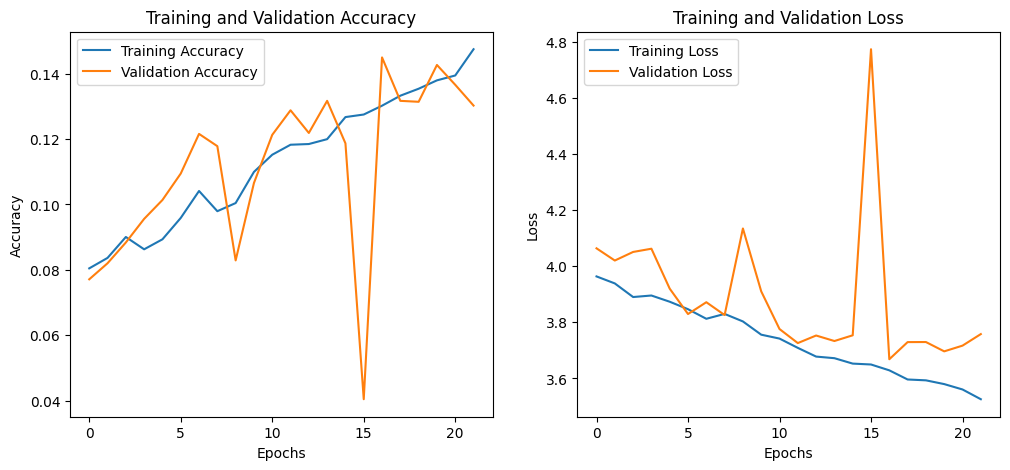

In [26]:
# Plot training and validation accuracy/loss curves
def plot_history(history):
    plt.figure(figsize=(12, 5))

    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

# Call the function to plot
plot_history(history)
